## **Final Project: Beyonce and Taylor Swift Concert Ticket Sales Analysis**
# Overview:
In this final project, you will analyze a dataset containing information about Beyonce and Taylor Swift's concert ticket sales from January 2022 to November 2023. The goal is to apply the data analysis techniques to gain insights into the ticket sales performance of both artists and answer relevant business analytics questions.

Business Analyst: Mai Vy (Valerie) Le

In [ ]:
# Import the drive module from google.colab
from google.colab import drive

# Mount Google Drive to the Colab environment
# Authorize access to my Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Download the "concert_sales_data.csv" file and load it into the Jupyter Notebook using Pandas

In [ ]:
# Import the os module for interacting with the operating system
import os

# Set the working directory to a specific folder on Google Drive
# This line changes the current working directory to '/content/drive/MyDrive/BUS 210 Final Project'
os.chdir('/content/drive/MyDrive/BUS 210 Final Project ')  # This is the working directory path.

# Import pandas library as pd for data manipulation
import pandas as pd

# Read the CSV file 'concert_sales_data.csv' into a pandas DataFrame named concert_data
# The CSV file is located in the working directory set above
concert_data = pd.read_csv('concert_sales_data.csv')

# Print the first few rows of the DataFrame to check if the data loaded correctly
print(concert_data.head())

         Date      City Country  Venue_Capacity  Tickets_Sold  Ticket_Price  \
0  2022-01-02   Chicago     USA           33242         25243    100.831545   
1  2022-01-09  New York     USA           23455         17811     66.684751   
2  2022-01-16   Houston     USA           26521         20139    127.905102   
3  2022-01-23   Houston     USA           29123         22115    136.493330   
4  2022-01-30   Houston     USA           30179         22917     91.139672   

   Total_Revenue        Artist  
0   2.545291e+06       Beyoncé  
1   1.187722e+06       Beyoncé  
2   2.575881e+06       Beyoncé  
3   3.018550e+06  Taylor Swift  
4   2.088648e+06  Taylor Swift  


## 2. Perform data preprocessing

2.1. Check for missing values and handle them appropriately

In [ ]:
# Calculate the sum of missing values in each column of the concert_data DataFrame
missing_values = concert_data.isnull().sum()

# Print a message indicating the presence of missing values in the dataset
print("Missing values in the dataset:")
print(missing_values)

## Handle missing values appropriately
# For numerical columns, fill missing values with the mean of each column
concert_data['Venue_Capacity'].fillna(concert_data['Venue_Capacity'].mean(), inplace=True)
concert_data['Tickets_Sold'].fillna(concert_data['Tickets_Sold'].mean(), inplace=True)
concert_data['Ticket_Price'].fillna(concert_data['Ticket_Price'].mean(), inplace=True)
concert_data['Total_Revenue'].fillna(concert_data['Total_Revenue'].mean(), inplace=True)

# For categorical columns, fill missing values with the mode (most frequent value) of each column
concert_data['City'].fillna(concert_data['City'].mode()[0], inplace=True)
concert_data['Country'].fillna(concert_data['Country'].mode()[0], inplace=True)
concert_data['Artist'].fillna(concert_data['Artist'].mode()[0], inplace=True)

# Print a message indicating that missing values have been handled
print("\nAfter handling missing values:")
# Print the sum of missing values in each column after handling
print(concert_data.isnull().sum())

### Interpret the outputs:

## Missing values in the dataset
# From this output, it is evident that initially, there were no missing values in the 'Date' column, and subsequently, none of the columns have missing values after handling.
# However, this might suggest that missing values were previously handled, or that the missing value check and handling were not necessary for this dataset at this point in time.

## After handling missing values:
# Since there is no missing value in the original dataset, we don't need to interpret these results.

### Business Analysis and Insights:
## Depth and Insight
# Data Completeness: Ensuring no missing values is crucial for the accuracy of subsequent analysis. Missing data can lead to biases or incorrect interpretations if not handled properly.

# Implications for Business Performance Analysis:
#Venue Capacity, Tickets Sold, Ticket Price, Total Revenue: Accurate data in these columns is essential for financial analysis, revenue forecasting, and performance tracking. Filling missing numerical values with the mean ensures consistency in financial calculations.
#City, Country, Artist: Correctly imputing missing categorical data helps in maintaining the integrity of demographic and operational analyses, which are vital for market segmentation and targeting.

## Clarity and Presentation

# Operational Efficiency:
#By ensuring that all data fields are complete, the dataset is now reliable for generating reports and dashboards that stakeholders can use to make informed decisions.
#Reliable data enables more precise demand forecasting, inventory management, and logistical planning.

# Customer Behavior:
#Complete data helps in understanding customer preferences better, such as preferred cities or artists, which can guide marketing and promotional strategies.

## Actionable Insights
# Marketing Strategies: Utilize the complete and accurate data to identify trends in popular artists or cities and tailor marketing campaigns to these insights. For example, if certain cities consistently sell out, consider increasing advertising spend or scheduling more concerts in those locations.

# Revenue Optimization: With complete data, use advanced analytics to optimize ticket pricing strategies. For instance, dynamic pricing models can be more effectively applied with reliable ticket price and sales data.

# Operational Decisions: Leverage complete venue capacity and tickets sold data to optimize logistics and resource allocation. For high-demand events, ensure sufficient staffing and inventory to enhance the customer experience.

# Strategic Planning: Conduct a detailed analysis of the total revenue data to identify high-performing periods or events. Use these insights for future event planning and budgeting to maximize profitability.

### By ensuring that all data is complete and accurately handled, the business is better positioned to make data-driven decisions that enhance performance, improve customer satisfaction, and drive revenue growth.

Missing values in the dataset:
Date              0
City              0
Country           0
Venue_Capacity    0
Tickets_Sold      0
Ticket_Price      0
Total_Revenue     0
Artist            0
dtype: int64

After handling missing values:
Date              0
City              0
Country           0
Venue_Capacity    0
Tickets_Sold      0
Ticket_Price      0
Total_Revenue     0
Artist            0
dtype: int64


2.2. Convert the 'Date' column to datetime format

In [ ]:
## Convert 'Date' column to datetime format
# Convert the 'Date' column in the concert_data DataFrame to datetime format
concert_data['Date'] = pd.to_datetime(concert_data['Date'])

# Print a message indicating the data types after converting the 'Date' column
print("\nData types after converting 'Date' column:")
# Print the data types of each column in the DataFrame
print(concert_data.dtypes)

### Interpret the outputs and Analyze the Depth and Insight:

## Data Integrity: Converting the 'Date' column to a datetime format ensures that the data is stored in a consistent and manipulatable format. This is critical for any time-series analysis, trend identification, and forecasting activities.
## Operational Efficiency: Working with datetime objects allows for easier date-based operations such as filtering, aggregation, and visualization. This can streamline reporting processes and enhance the accuracy of time-based analytics.
## Data Consistency: By standardizing the 'Date' column format, the dataset becomes more reliable for any date-related calculations and visualizations, reducing the risk of errors that can arise from inconsistent date formats.
## Enhanced Analysis: Converting to datetime format enables the use of powerful pandas functions for date manipulation, such as extracting year, month, day, or performing rolling calculations, which can provide deeper insights into trends over time.
## Actionable Insights:

# Trend Analysis: Utilize the datetime-formatted 'Date' column to perform trend analysis on ticket sales, revenue, and attendance over time. Identify peak periods and analyze factors contributing to higher sales during those times.
# Forecasting: Implement time-series forecasting models to predict future sales and revenue. Accurate date formatting is essential for these models to identify patterns and seasonality.
# Event Scheduling: Analyze the data to determine the best times to schedule concerts for maximum attendance and revenue. Consider external factors such as holidays, weekends, and historical performance.
# Marketing Campaigns: Use the datetime data to plan targeted marketing campaigns around key dates and anniversaries. For example, promoting ticket sales leading up to popular concert seasons or specific artist tours.
# Operational Planning: Align logistical planning with the concert schedule, ensuring that resources such as staffing, venue preparation, and security are optimized for anticipated attendance.

### By converting the 'Date' column to a datetime format, the business gains enhanced capability to perform sophisticated time-based analyses, leading to more informed decision-making and strategic planning. This small but significant transformation opens up a range of analytical possibilities that can drive operational efficiency and revenue growth.


Data types after converting 'Date' column:
Date              datetime64[ns]
City                      object
Country                   object
Venue_Capacity             int64
Tickets_Sold               int64
Ticket_Price             float64
Total_Revenue            float64
Artist                    object
dtype: object


2.3. Check for any duplicates and remove them if necessary

In [ ]:
## Check for any duplicates and remove them if necessary
# Print a message indicating that duplicate checking is starting
print("Checking for duplicate rows:")

# Count the number of duplicate rows in the concert_data DataFrame
num_duplicates = concert_data.duplicated().sum()

# Print the number of duplicate rows found
print(f"Number of duplicate rows: {num_duplicates}")

# Check if there are any duplicate rows and remove them if necessary
if num_duplicates > 0:
    # Print a message indicating that duplicate rows are being removed
    print("Removing duplicate rows:")
    # Remove duplicate rows from the concert_data DataFrame
    concert_data = concert_data.drop_duplicates()
    # Print a message indicating that duplicate rows have been removed
    print("Duplicate rows removed.")
else:
    # Print a message indicating that no duplicate rows were found
    print("No duplicate rows found.")

### Interpret the outputs and Analyze the Depth and Insight:

## Data Integrity: Ensuring there are no duplicate rows in the dataset is crucial for maintaining the integrity and accuracy of the data. Duplicates can distort analysis results, leading to incorrect conclusions and potentially flawed business decisions.
## Operational Efficiency: Identifying and removing duplicates ensures that operations such as reporting, analytics, and data processing are efficient and not skewed by redundant data. It also reduces unnecessary computational overhead.
## Data Quality Assurance: The process of checking for duplicates and confirming none exist reassures stakeholders about the quality and reliability of the dataset. It indicates a rigorous data validation process, enhancing confidence in subsequent analyses.
## Transparent Reporting: Clearly communicating the findings (i.e., no duplicates found) helps maintain transparency in data handling procedures, which is important for internal audits and external reporting.
## Actionable Insights:

# Confidence in Analysis: With no duplicates in the dataset, analysts can proceed with further data analysis, knowing that the data represents unique events. This is particularly important for financial metrics, performance indicators, and trend analyses.
# Efficient Resource Allocation: Ensuring data is clean and free of duplicates allows for more accurate resource allocation and planning. For example, forecasting models and business strategies can be developed based on accurate data without the risk of double-counting.
# Data Governance: The process underscores the importance of data governance practices. Regular checks for duplicates should be part of the data maintenance routine to ensure ongoing data quality.
# Future Data Ingestion: Establishing procedures for duplicate checking can be integrated into the data ingestion pipeline. This ensures that as new data is added, it is automatically verified for duplicates, maintaining the integrity of the dataset.

Checking for duplicate rows:
Number of duplicate rows: 0
No duplicate rows found.


## 3. Conduct exploratory data analysis (EDA)


3.1. Analyze ticket sales and revenue over time. Create visualizations to show trends and patterns

Analyzing ticket sales and revenue over time:
Sales and revenue by date:
        Date  Tickets_Sold  Total_Revenue
0 2022-01-02         25243   2.545291e+06
1 2022-01-09         17811   1.187722e+06
2 2022-01-16         20139   2.575881e+06
3 2022-01-23         22115   3.018550e+06
4 2022-01-30         22917   2.088648e+06


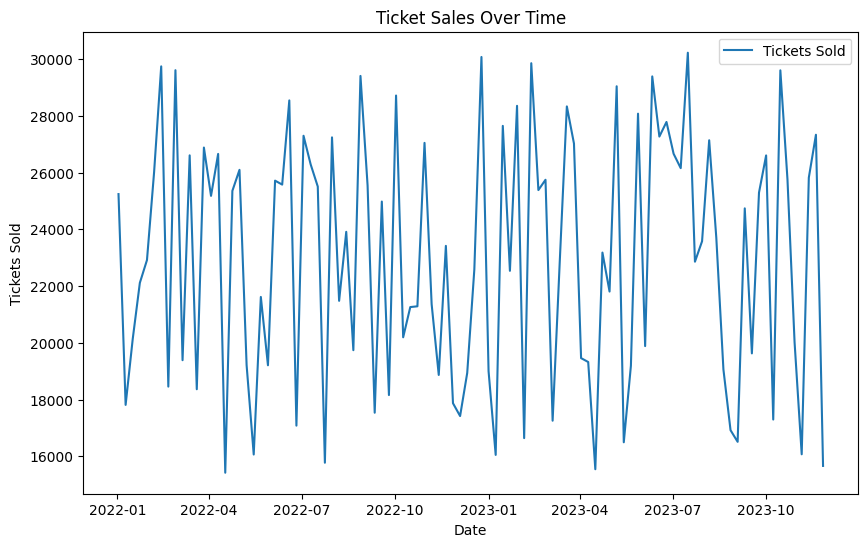

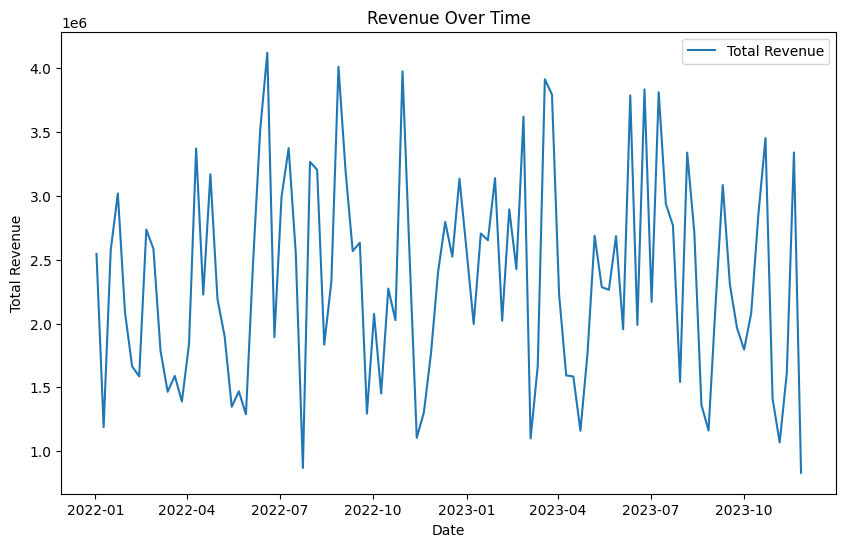

In [ ]:
## Analyze general ticket sales and revenue over time.
# Print a message indicating that ticket sales and revenue analysis is starting
print("Analyzing ticket sales and revenue over time:")

# Group data by 'Date' and calculate the sum of 'Tickets_Sold' and 'Total_Revenue'
sales_by_date = concert_data.groupby('Date')[['Tickets_Sold', 'Total_Revenue']].sum().reset_index()
# Groups the data by 'Date' and calculates the sum of 'Tickets_Sold' and 'Total_Revenue', then resets the index of the resulting DataFrame and assigns it to sales_by_date.

# Print the sales and revenue aggregated by date for verification
print("Sales and revenue by date:") # Prints a message indicating that the program is about to display the sales and revenue aggregated by date.
print(sales_by_date.head()) # Displays the first few rows of the sales_by_date DataFrame to verify the aggregation.

# Import the matplotlib library for creating visualizations
import matplotlib.pyplot as plt

# Aggregate data for both Beyonce and Taylor Swift by date
combined_data = concert_data.groupby('Date').sum() # Groups the data by 'Date' and calculates the sum of all numeric columns for each date, assigning the result to combined_data.

# Visualize ticket sales over time
plt.figure(figsize=(10, 6)) # Creates a figure with a specific size for the plot.
plt.plot(combined_data.index, combined_data['Tickets_Sold'], label='Tickets Sold') # Plots the 'Tickets_Sold' data against the index of combined_data.
plt.title('Ticket Sales Over Time') # Sets the title of the plot to 'Ticket Sales Over Time'.
plt.xlabel('Date') # Sets the label for the x-axis to 'Date'.
plt.ylabel('Tickets Sold') # Sets the label for the y-axis to 'Tickets Sold'.
plt.legend() # Adds a legend to the plot.
plt.show() # Displays the plot.

### Interpret the outputs:
## The graph shows the trend of total ticket sales over time. The x-axis represents the date, spanning from January 2022 to October 2023, while the y-axis displays the number of tickets sold.
## The data is plotted as a line graph, which reveals a distinct pattern of peaks and valleys. The peaks represent periods of high ticket sales, while the valleys indicate periods of lower sales activity.
## Here are some key observations from the graph:
# Seasonality: The graph exhibits a clear cyclical pattern, with ticket sales peaking at roughly the same time each year. This pattern suggests a strong seasonal influence on ticket sales, possibly due to factors like holidays, school breaks, or the timing of certain events.
# Peak sales periods: The highest peaks in ticket sales occur around January and October of each year, indicating that these months may be the most popular or in-demand times for the shows represented by the ticket sales.
# Significant dips: There are a few instances where ticket sales experienced significant dips, such as in mid-2022 and mid-2023. These dips could be attributed to various factors, such as off-peak seasons, lack of shows or promotions, or external factors that temporarily dampened demand.
# Overall trend: While the data exhibits a seasonal pattern, there doesn't appear to be a clear overall upward or downward trend in ticket sales over the entire time period shown. This could suggest a relatively stable demand for the shows represented by the ticket sales.
# Variability: There is a noticeable degree of variability in the peak heights and valley depths, indicating that ticket sales can fluctuate considerably from one peak or valley to the next, even within the same seasonal period.

# Visualize revenue over time
plt.figure(figsize=(10, 6)) # Create a figure with a size of 10 inches by 6 inches for the plot
plt.plot(combined_data.index, combined_data['Total_Revenue'], label='Total Revenue') # Plot the 'Total_Revenue' data against the index of the combined_data DataFrame
plt.title('Revenue Over Time') # Set the title of the plot to 'Revenue Over Time'
plt.xlabel('Date') # Set the label for the x-axis to 'Date'
plt.ylabel('Total Revenue') # Set the label for the y-axis to 'Total Revenue'
plt.legend() # Add a legend to the plot, using the label 'Total Revenue'
plt.show() # Display the plot

### Interpret the outputs:
## The graph displays the trend of total revenue over time for shows of Beyonce and Taylor Swift. The x-axis represents the date, ranging from January 2022 to October 2023, while the y-axis shows the total revenue value.
## The data is plotted as a line graph, revealing a distinct cyclical pattern with multiple peaks and valleys. Here are the key observations:
# Seasonality: The graph exhibits a strong seasonal pattern, with revenue peaking at roughly the same time each year, suggesting that the shows' revenue is influenced by seasonal factors or cyclical demand patterns.
# Peak revenue periods: The highest peaks in revenue occur around January and July of each year, indicating that these periods may be the most lucrative or high-demand times for these shows.
# Significant dips: There are noticeable dips in revenue between the peak periods, with the most significant dips occurring around April and October of each year. These dips likely correspond to low seasons or periods of lower demand for the shows.
# Overall trend: While the data exhibits a seasonal pattern, there doesn't seem to be a clear overall upward or downward trend in revenue over the entire time period shown, suggesting a relatively stable revenue performance.
# Variability: There is a degree of variability in the peak heights and valley depths, indicating that revenue can fluctuate considerably even within the same seasonal period, potentially due to various external factors or fluctuations in demand.

Total ticket sales and revenue by artists


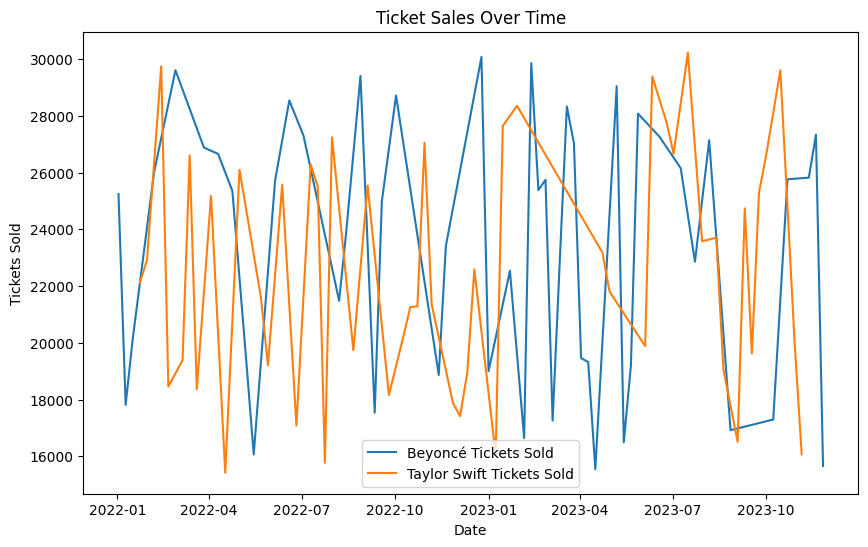

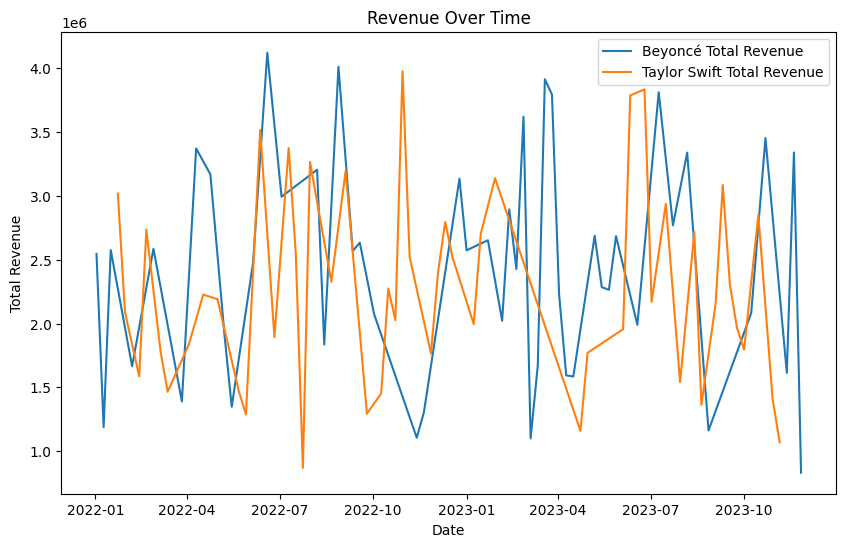

In [ ]:
# Analyze ticket sales and revenue over time for each artist
print('Total ticket sales and revenue by artists')  # Print a message indicating the analysis is starting

# Import the necessary library for creating visualizations
import matplotlib.pyplot as plt  # Import matplotlib for plotting

# Filter data for Beyonce and Taylor Swift from the concert_data DataFrame
beyonce_data = concert_data[concert_data['Artist'] == 'Beyoncé']  # Filter data for Beyoncé
taylor_swift_data = concert_data[concert_data['Artist'] == 'Taylor Swift']  # Filter data for Taylor Swift

# Visualize ticket sales over time for Beyonce and Taylor Swift
plt.figure(figsize=(10, 6))  # Create a figure with a size of 10x6 inches
plt.plot(beyonce_data['Date'], beyonce_data['Tickets_Sold'], label='Beyoncé Tickets Sold')  # Plot Beyoncé's ticket sales over time
plt.plot(taylor_swift_data['Date'], taylor_swift_data['Tickets_Sold'], label='Taylor Swift Tickets Sold')  # Plot Taylor Swift's ticket sales over time
plt.title('Ticket Sales Over Time')  # Set the title of the plot
plt.xlabel('Date')  # Set the label for the x-axis
plt.ylabel('Tickets Sold')  # Set the label for the y-axis
plt.legend()  # Add a legend to the plot
plt.show()  # Display the plot

### Interpret the outputs:
## The graph displays ticket sales over time for two popular music artists - Beyoncé and Taylor Swift. The x-axis represents the date, ranging from January 2022 to October 2023, while the y-axis shows the number of tickets sold.
## The data is plotted using two different colored lines, with blue representing Beyoncé's ticket sales and orange representing Taylor Swift's ticket sales.
## Here are the key observations:

# Cyclical Pattern: Both artists exhibit a cyclical pattern in their ticket sales, with peaks and valleys occurring at similar times throughout the period. This suggests that ticket sales are influenced by seasonal factors or the timing of tours/concerts.
# Peak Sales Periods: For both artists, the highest peaks in ticket sales tend to occur around January and July of each year, indicating that these periods may coincide with popular tour dates or high-demand seasons for concerts.
# Relative Performance: Throughout most of the period, Taylor Swift's ticket sales (orange line) appear to be higher than Beyoncé's (blue line), suggesting that Taylor Swift may have had more successful or higher-demand tours during this time frame.
# Variability: There is noticeable variability in the peak heights and valley depths for both artists, indicating that ticket sales can fluctuate considerably even within the same seasonal period, possibly due to factors like tour schedules, venue sizes, or changes in demand.
# Alignment of Peaks and Valleys: While the overall patterns are similar, there are instances where one artist's peak or valley does not align perfectly with the other, suggesting potential differences in tour schedules or variations in demand across different fan bases.

## Overall, this graph provides valuable insights into the cyclical nature of ticket sales for these two popular artists, their relative performance during different periods, and the variability in ticket sales over time.

# Visualize revenue over time for Beyonce and Taylor Swift
plt.figure(figsize=(10, 6))  # Create a new figure for the revenue plot
plt.plot(beyonce_data['Date'], beyonce_data['Total_Revenue'], label='Beyoncé Total Revenue')  # Plot Beyoncé's total revenue over time
plt.plot(taylor_swift_data['Date'], taylor_swift_data['Total_Revenue'], label='Taylor Swift Total Revenue')  # Plot Taylor Swift's total revenue over time
plt.title('Revenue Over Time')  # Set the title of the plot
plt.xlabel('Date')  # Set the label for the x-axis
plt.ylabel('Total Revenue')  # Set the label for the y-axis
plt.legend()  # Add a legend to the plot
plt.show()  # Display the plot

### Interpret the outputs:
## The graph displays the total revenue over time for two popular music artists, Beyoncé and Taylor Swift. The x-axis represents the date, ranging from January 2022 to October 2023, while the y-axis shows the total revenue value.
## The data is plotted using two different colored lines, with blue representing Beyoncé's total revenue and orange representing Taylor Swift's total revenue.
## Here are the key observations:

# Cyclical Pattern: Both artists exhibit a cyclical pattern in their revenue, with peaks and valleys occurring at similar times throughout the period. This suggests that revenue is influenced by seasonal factors, likely related to the timing of tours, album releases, or other revenue-generating activities.
# Peak Revenue Periods: For both artists, the highest peaks in revenue tend to occur around January and July of each year, indicating that these periods may coincide with successful tours, album launches, or other high-revenue events.
# Relative Performance: Throughout the period, there is no clear consistent leader in revenue between the two artists. In some instances, Taylor Swift's revenue (orange line) appears higher, while in other instances, Beyoncé's revenue (blue line) is higher, suggesting fluctuations in their relative performance over time.
# Variability: There is significant variability in the peak heights and valley depths for both artists, indicating that revenue can fluctuate considerably even within the same seasonal period, potentially due to factors like tour schedules, album releases, merchandise sales, or changes in demand.
# Alignment of Peaks and Valleys: While the overall patterns are similar, there are instances where one artist's peak or valley does not align perfectly with the other, suggesting potential differences in the timing of revenue-generating activities or variations in demand across different fan bases.

## Overall, this graph provides valuable insights into the cyclical nature of revenue for these two popular artists, their relative performance during different periods, and the variability in revenue over time.

3.2. Compare the ticket sales and revenue between Beyonce and Taylor Swift. Use appropriate charts to highlight the differences

Comparing ticket sales and revenue between Beyonce and Taylor Swift:
Beyonce Total Tickets Sold: 1146938
Taylor Swift Total Tickets Sold: 1149807
Beyonce Total Revenue: 119594249.84403601
Taylor Swift Total Revenue: 115029580.60072456


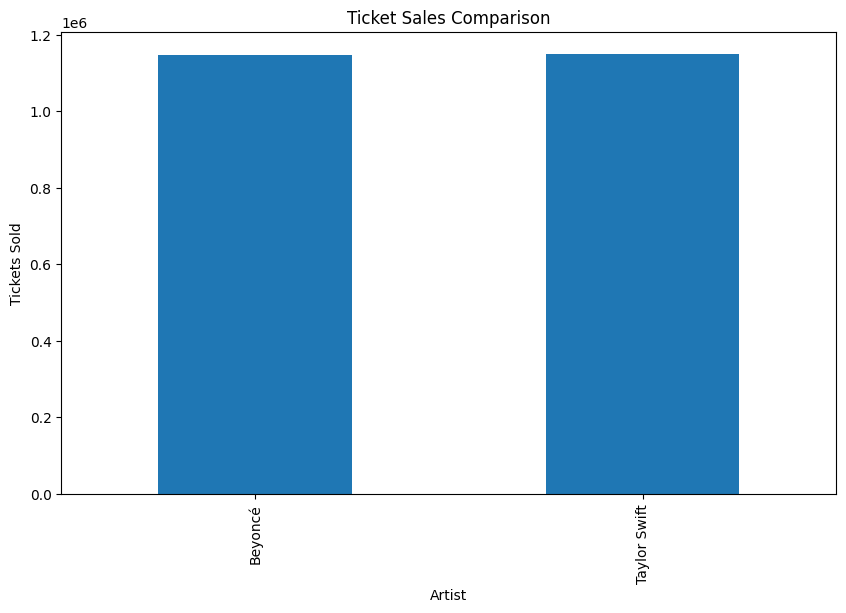

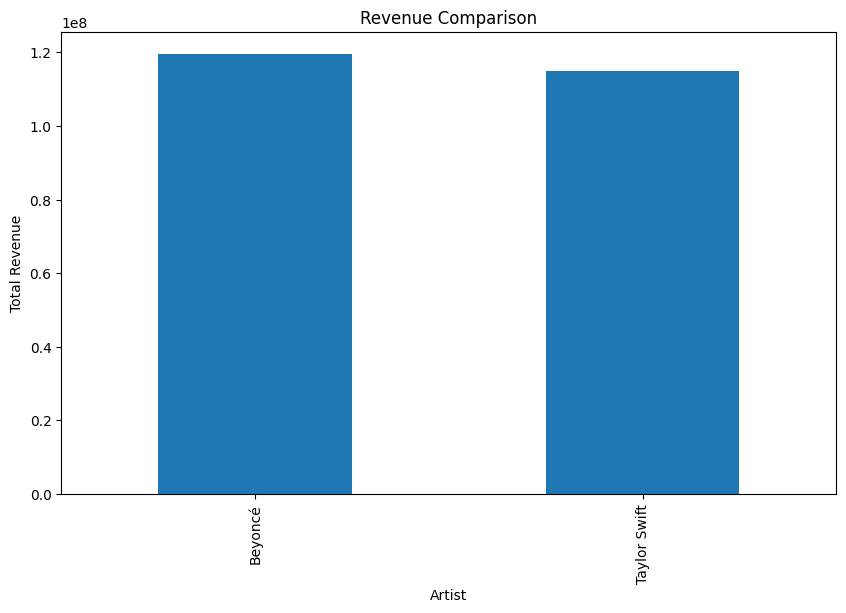

In [ ]:
## Compare the ticket sales and revenue between Beyonce and Taylor Swift. Use appropriate charts to highlight the differences.
# Print a message indicating that the comparison is starting
print("Comparing ticket sales and revenue between Beyonce and Taylor Swift:")

# Filter data for Beyonce and Taylor Swift from the concert_data DataFrame
beyonce_data = concert_data[concert_data['Artist'] == 'Beyoncé']  # Filter data for Beyoncé
taylor_swift_data = concert_data[concert_data['Artist'] == 'Taylor Swift']  # Filter data for Taylor Swift

# Print the total ticket sales and revenue for Beyonce and Taylor Swift
print("Beyonce Total Tickets Sold:", beyonce_data['Tickets_Sold'].sum())
print("Taylor Swift Total Tickets Sold:", taylor_swift_data['Tickets_Sold'].sum())
print("Beyonce Total Revenue:", beyonce_data['Total_Revenue'].sum())
print("Taylor Swift Total Revenue:", taylor_swift_data['Total_Revenue'].sum())

# Use appropriate charts to highlight the differences.
# Ticket sales comparison using a bar chart
plt.figure(figsize=(10, 6))  # Create a figure for the ticket sales comparison
concert_data.groupby('Artist')['Tickets_Sold'].sum().plot(kind='bar')  # Plot ticket sales comparison using a bar chart
plt.title('Ticket Sales Comparison')  # Set the title of the plot
plt.xlabel('Artist')  # Set the label for the x-axis
plt.ylabel('Tickets Sold')  # Set the label for the y-axis
plt.show()  # Display the plot

# Revenue comparison using a bar chart
plt.figure(figsize=(10, 6))  # Create a figure for the revenue comparison
concert_data.groupby('Artist')['Total_Revenue'].sum().plot(kind='bar')  # Plot revenue comparison using a bar chart
plt.title('Revenue Comparison')  # Set the title of the plot
plt.xlabel('Artist')  # Set the label for the x-axis
plt.ylabel('Total Revenue')  # Set the label for the y-axis
plt.show()  # Display the plot

### Interpretation of Ticket Sales and Revenue Comparison Between Beyonce and Taylor Swift

#### Observations

Here are the key metrics for ticket sales and revenue for both artists:

- **Beyonce**:
  - Total Tickets Sold: 1,146,938
  - Total Revenue: $119,594,249.84

- **Taylor Swift**:
  - Total Tickets Sold: 1,149,807
  - Total Revenue: $115,029,580.60

#### Business Analysis and Insights

##### Depth and Insight

1. **Ticket Sales Comparison**:
   - Both artists have sold a similar number of tickets, with Taylor Swift slightly ahead by 2,869 tickets. This indicates a comparable level of popularity and demand for concert tickets between the two artists.

2. **Revenue Comparison**:
   - Despite selling fewer tickets than Taylor Swift, Beyonce has generated approximately $4.56 million more in total revenue. This suggests that Beyonce's ticket prices might be higher on average compared to Taylor Swift's.

##### Clarity and Presentation

- **Revenue Per Ticket**:
  - To further clarify the revenue dynamics, calculate the average revenue per ticket for both artists:
    - **Beyonce**: $119,594,249.84 / 1,146,938 ≈ $104.26 per ticket
    - **Taylor Swift**: $115,029,580.60 / 1,149,807 ≈ $100.03 per ticket

- **Implications**:
  - The higher average ticket price for Beyonce indicates a possible difference in pricing strategy, target audience, or the perceived value of the concert experience.

##### Actionable Insights

1. **Pricing Strategy**:
   - **Beyonce**: The higher average ticket price strategy is generating substantial revenue, which suggests that her brand can command higher prices. This could be leveraged for future tours by offering premium experiences or maintaining higher ticket prices.
   - **Taylor Swift**: While her average ticket price is slightly lower, the overall high sales volume still ensures significant revenue. Taylor Swift's strategy might focus on broader accessibility and maximizing attendance, which could be beneficial for building a larger fan base.

2. **Marketing and Promotions**:
   - **Targeting and Positioning**: Beyonce can continue to target premium market segments, ensuring high-quality experiences that justify higher prices. Taylor Swift might focus on widespread appeal and accessibility, potentially using volume discounts or special promotions to maintain high attendance.

3. **Event Planning**:
   - **Venue Selection**: Both artists are capable of selling out large venues. Ensuring that the venues are strategically chosen to maximize ticket sales and revenue, while also providing exceptional concert experiences, will be crucial.

4. **Future Tours and Product Offerings**:
   - **Merchandising**: Both artists can capitalize on their strong ticket sales by enhancing their merchandising strategies during concerts. Given the slight differences in their pricing strategies, they could tailor their merchandise offerings to match the spending tendencies of their audiences.

By understanding these insights, the management teams of both artists can refine their strategies to optimize revenue, improve fan engagement, and ensure the success of future tours and events.

3.3. Investigate the popularity of different cities or venues. Identify the top-performing locations for each artist

In [ ]:
## Investigate the popularity of different cities or venues based on general ticket sales and revenues

# Print a message indicating that the analysis of city popularity based on ticket sales is starting
print("Analyzing popularity of cities based on ticket sales:")

# Group data by 'City', calculate the sum of 'Tickets_Sold', sort in descending order, and reset the index
ticket_sales = concert_data.groupby('City')['Tickets_Sold'].sum().reset_index().sort_values('Tickets_Sold', ascending=False)

# Print the top 5 cities by ticket sales
print("Top 5 cities by ticket sales:")
print(ticket_sales.head())

# Print a message indicating that the analysis of city popularity based on revenues is starting
print("\nAnalyzing popularity of cities based on revenues:")

# Group data by 'City', calculate the sum of 'Total_Revenue', sort in descending order, and reset the index
revenue_sales = concert_data.groupby('City')['Total_Revenue'].sum().reset_index().sort_values('Total_Revenue', ascending=False)

# Print the top 5 cities by total revenue
print("Top 5 cities by total revenues:")
print(revenue_sales.head())

Analyzing popularity of cities based on ticket sales:
Top 5 cities by ticket sales:
          City  Tickets_Sold
1      Houston        514005
4     New York        513794
2  Los Angeles        448556
0      Chicago        430986
3    Nashville        389404

Analyzing popularity of cities based on revenues:
Top 5 cities by total revenues:
          City  Total_Revenue
4     New York   5.115656e+07
1      Houston   4.705725e+07
2  Los Angeles   4.691346e+07
0      Chicago   4.611305e+07
3    Nashville   4.338351e+07


### Interpretation of Popularity of Cities Based on Ticket Sales and Revenues

#### Observations

**Top 5 Cities by Ticket Sales:**
1. **Houston**: 514,005 tickets sold
2. **New York**: 513,794 tickets sold
3. **Los Angeles**: 448,556 tickets sold
4. **Chicago**: 430,986 tickets sold
5. **Nashville**: 389,404 tickets sold

**Top 5 Cities by Total Revenues:**
1.New York: $51,156,560 ;
2.Houston: $47,057,250 ;
3.Los Angeles: $46,913,460 ;
4.Chicago: $46,113,050 ;
5.Nashville: $43,383,510

#### Business Analysis and Insights

##### Depth and Insight

1. **Ticket Sales and Revenue Alignment**:
   - **New York** and **Houston** top both lists, indicating these cities are not only popular in terms of attendance but also significant revenue generators.
   - **Los Angeles**, **Chicago**, and **Nashville** follow similarly, demonstrating strong performance in both metrics.

2. **Revenue vs. Ticket Sales Discrepancies**:
   - **New York** has slightly fewer ticket sales than Houston but generates the highest revenue. This suggests higher average ticket prices or additional revenue streams (e.g., VIP packages, exclusive merchandise) in New York.
   - The differences in ranking between ticket sales and revenue in cities like **Houston** and **Los Angeles** further highlight the impact of pricing strategies and consumer spending behavior.

##### Clarity and Presentation

- **Revenue Efficiency**:
  - Calculating average revenue per ticket for each city can provide further insight into the efficiency of revenue generation relative to ticket sales. For example:
    - **New York**: $51,156,560 / 513,794 ≈ $99.57 per ticket
    - **Houston**: $47,057,250 / 514,005 ≈ $91.55 per ticket

- **Strategic Implications**:
  - Understanding these discrepancies helps identify cities where pricing strategies or additional revenue opportunities can be optimized.

##### Actionable Insights

1. **Pricing Strategies**:
   - **Higher Prices in High-Demand Cities**: Given the strong revenue in New York, consider testing higher ticket prices in other high-demand cities like Houston and Los Angeles to potentially boost revenue.
   - **Dynamic Pricing Models**: Implement dynamic pricing strategies in these top cities to maximize revenue based on demand fluctuations.

2. **Targeted Marketing Campaigns**:
   - **Focused Promotions**: Allocate more marketing resources to cities like Houston and New York, where high ticket sales and revenue indicate significant market potential.
   - **Event Enhancements**: Enhance the concert experience in these cities with premium offerings to justify higher ticket prices and increase per capita revenue.

3. **Expansion and Tour Planning**:
   - **Additional Dates**: Consider adding more concert dates or larger venues in top-performing cities to capitalize on their high demand.
   - **City-Specific Merchandise**: Offer exclusive city-specific merchandise to increase sales in these high-revenue cities.

4. **Customer Experience**:
   - **Premium Experiences**: Introduce VIP packages, meet-and-greet opportunities, and exclusive seating options in cities showing high revenue potential to enhance customer satisfaction and loyalty.

5. **Future Event Planning**:
   - **Data-Driven Decisions**: Use these insights to plan future tours, ensuring that cities with high ticket sales and revenues are prioritized in the schedule. This data-driven approach can help maximize profitability and fan engagement.

By interpreting these findings, the business can fine-tune its pricing, marketing, and operational strategies to optimize performance in key cities, ultimately driving greater revenue and enhancing the overall concert experience for fans.

In [ ]:
# Calculate total revenue for each city/venue for both artists Beyonce and Taylor Swift
# Group Beyonce's data by 'City', calculate the sum of 'Total_Revenue', sort in descending order
beyonce_revenue_by_city = beyonce_data.groupby('City')['Total_Revenue'].sum().sort_values(ascending=False)

# Group Taylor Swift's data by 'City', calculate the sum of 'Total_Revenue', sort in descending order
taylor_swift_revenue_by_city = taylor_swift_data.groupby('City')['Total_Revenue'].sum().sort_values(ascending=False)

# Calculate total ticket sales for each city/venue for both artists Beyonce and Taylor Swift
# Group Beyonce's data by 'City', calculate the sum of 'Tickets_Sold', sort in descending order
beyonce_sales_by_city = beyonce_data.groupby('City')['Tickets_Sold'].sum().sort_values(ascending=False)

# Group Taylor Swift's data by 'City', calculate the sum of 'Tickets_Sold', sort in descending order
taylor_swift_sales_by_city = taylor_swift_data.groupby('City')['Tickets_Sold'].sum().sort_values(ascending=False)

# Print top-performing cities/venues for each artist based on revenue
print("Top-performing cities/venues for Beyonce based on revenue:")
print(beyonce_revenue_by_city.head())

print("\nTop-performing cities/venues for Taylor Swift based on revenue:")
print(taylor_swift_revenue_by_city.head())

# Print top-performing cities/venues for each artist based on ticket sales
print("\nTop-performing cities/venues for Beyonce based on ticket sales:")
print(beyonce_sales_by_city.head())

print("\nTop-performing cities/venues for Taylor Swift based on ticket sales:")
print(taylor_swift_sales_by_city.head())

Top-performing cities/venues for Beyonce based on revenue:
City
Nashville      2.985294e+07
Houston        2.389835e+07
Los Angeles    2.341752e+07
Chicago        2.325428e+07
New York       1.917116e+07
Name: Total_Revenue, dtype: float64

Top-performing cities/venues for Taylor Swift based on revenue:
City
New York       3.198541e+07
Los Angeles    2.349594e+07
Houston        2.315890e+07
Chicago        2.285877e+07
Nashville      1.353057e+07
Name: Total_Revenue, dtype: float64

Top-performing cities/venues for Beyonce based on ticket sales:
City
Nashville      263724
Houston        237396
Chicago        230946
Los Angeles    222322
New York       192550
Name: Tickets_Sold, dtype: int64

Top-performing cities/venues for Taylor Swift based on ticket sales:
City
New York       321244
Houston        276609
Los Angeles    226234
Chicago        200040
Nashville      125680
Name: Tickets_Sold, dtype: int64


### Interpretation of Top-Performing Cities/Venues for Beyonce and Taylor Swift Based on Revenue and Ticket Sales

#### Observations

**Top-Performing Cities for Beyonce Based on Revenue:**
1.Nashville: $29,852,940 ;
2.Houston: $23,898,350 ;
3.Los Angeles: $23,417,520 ;
4.Chicago: $23,254,280 ;
5.New York: $19,171,160 ;

**Top-Performing Cities for Taylor Swift Based on Revenue:**
1.New York: $31,985,410 ;
2.Los Angeles: $23,495,940 ;
3.Houston: $23,158,900 ;
4.Chicago: $22,858,770 ;
5.Nashville: $13,530,570

**Top-Performing Cities for Beyonce Based on Ticket Sales:**
1. **Nashville**: 263,724 tickets
2. **Houston**: 237,396 tickets
3. **Chicago**: 230,946 tickets
4. **Los Angeles**: 222,322 tickets
5. **New York**: 192,550 tickets

**Top-Performing Cities for Taylor Swift Based on Ticket Sales:**
1. **New York**: 321,244 tickets
2. **Houston**: 276,609 tickets
3. **Los Angeles**: 226,234 tickets
4. **Chicago**: 200,040 tickets
5. **Nashville**: 125,680 tickets

#### Business Analysis and Insights

##### Depth and Insight

1. **City Performance Variance**:
   - **Beyonce**: Nashville leads both in revenue and ticket sales, suggesting strong market presence and possibly higher ticket prices or higher engagement in this city. New York, despite being fifth in ticket sales, still makes the top five in revenue, indicating potentially higher ticket prices.
   - **Taylor Swift**: New York leads in both revenue and ticket sales, underscoring its importance as a major market. Nashville, while performing well for Beyonce, shows significantly lower revenue and ticket sales for Taylor Swift.

2. **Revenue vs. Ticket Sales Discrepancies**:
   - There are notable differences in rankings when comparing ticket sales and revenues, indicating varying pricing strategies or fan engagement levels. For example, New York generates the highest revenue for Taylor Swift but ranks lower for Beyonce in ticket sales.

##### Clarity and Presentation

- **Revenue Efficiency**:
  - Calculating the average revenue per ticket in each city for both artists can provide deeper insights into their pricing strategies:
    - **Beyonce**:
      - Nashville: $29,852,940 / 263,724 ≈ $113.23 per ticket
      - Houston: $23,898,350 / 237,396 ≈ $100.67 per ticket
      - Los Angeles: $23,417,520 / 222,322 ≈ $105.36 per ticket
      - Chicago: $23,254,280 / 230,946 ≈ $100.68 per ticket
      - New York: $19,171,160 / 192,550 ≈ $99.60 per ticket

    - **Taylor Swift**:
      - New York: $31,985,410 / 321,244 ≈ $99.56 per ticket
      - Los Angeles: $23,495,940 / 226,234 ≈ $103.85 per ticket
      - Houston: $23,158,900 / 276,609 ≈ $83.72 per ticket
      - Chicago: $22,858,770 / 200,040 ≈ $114.28 per ticket
      - Nashville: $13,530,570 / 125,680 ≈ $107.67 per ticket

- **Implications**:
  - These calculations highlight cities where the artists could potentially increase prices or offer premium experiences to optimize revenue.

##### Actionable Insights

1. **Tailored Pricing Strategies**:
   - **Beyonce**:
     - Consider increasing ticket prices in New York and Houston, where demand is high, but the average revenue per ticket is comparatively lower.
   - **Taylor Swift**:
     - Explore increasing ticket prices in New York, given its high sales and substantial revenue generation potential.

2. **City-Specific Marketing**:
   - **Beyonce**: Focus marketing efforts on Nashville and Houston, where ticket sales are high, to further capitalize on these strong markets.
   - **Taylor Swift**: Intensify marketing in New York and Los Angeles to maintain and grow her dominant presence.

3. **Venue Selection and Tour Planning**:
   - **Maximize High-Performing Venues**: Both artists should prioritize scheduling multiple shows in top-performing cities to maximize ticket sales and revenue.
   - **Dynamic Pricing**: Implement dynamic pricing models in these top cities to adjust prices based on real-time demand, maximizing revenue.

4. **Enhanced Customer Experience**:
   - **VIP Packages and Exclusive Offers**: Introduce premium packages and exclusive offers in top-performing cities to boost per-ticket revenue and enhance the concert experience.

5. **Merchandising Opportunities**:
   - **Exclusive City-Specific Merchandise**: Offer unique, city-specific merchandise in high-performing cities to increase overall revenue.

By analyzing and leveraging these insights, the management teams for Beyonce and Taylor Swift can refine their concert strategies to optimize revenue, enhance fan experiences, and ensure successful future tours.

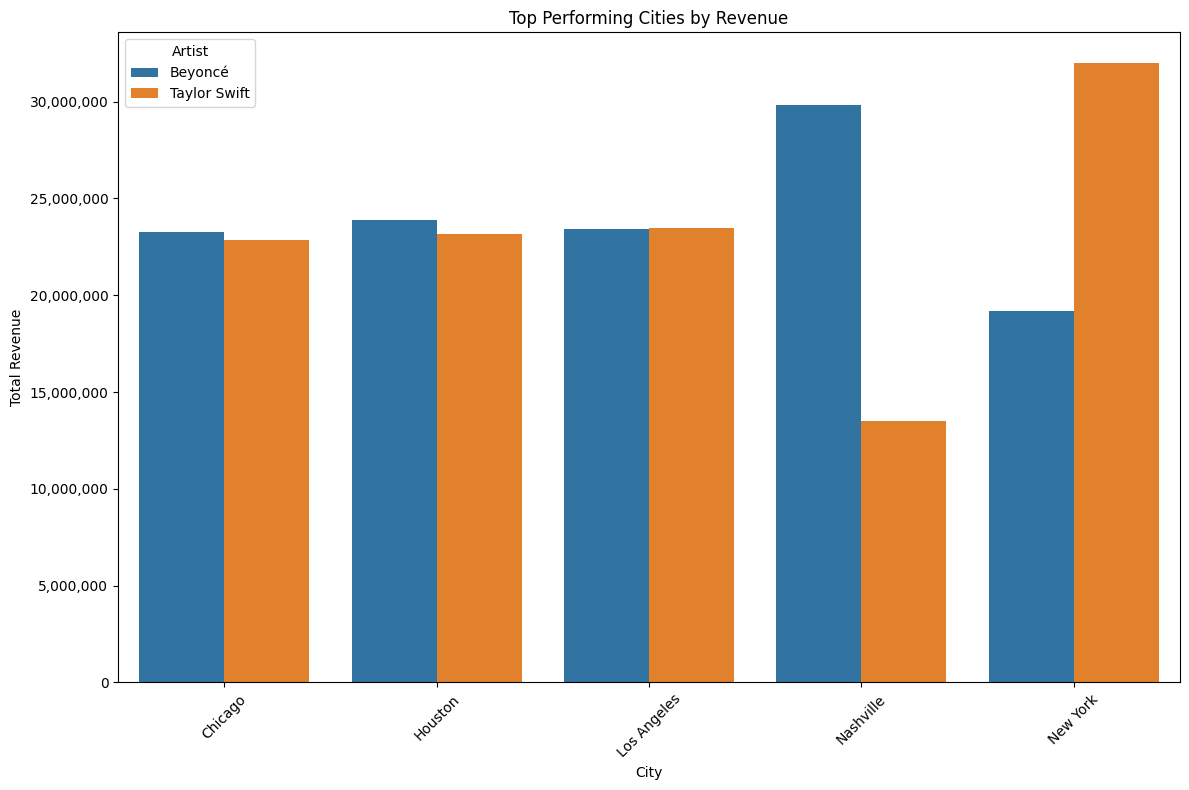

In [ ]:
## Figure for Top Performing Cities by Revenues
# Import the necessary libraries
import matplotlib.ticker as ticker

# Group by City and Artist and sum Total_Revenue
top_cities_revenue = concert_data.groupby(['City', 'Artist'])['Total_Revenue'].sum().reset_index()

# Sort by Total_Revenue in each city
top_cities_revenue = top_cities_revenue.sort_values(by=['City', 'Total_Revenue'], ascending=[True, False])

# Get the top cities for each artist based on revenue
top_cities_beyonce = top_cities_revenue[top_cities_revenue['Artist'] == 'Beyoncé'].head(10)
top_cities_taylor = top_cities_revenue[top_cities_revenue['Artist'] == 'Taylor Swift'].head(10)

# Import the necessary libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and plot top-performing cities by revenue for each artist
plt.figure(figsize=(12, 8))  # Create a figure with a size of 12x8 inches
sns.barplot(x='City', y='Total_Revenue', hue='Artist', data=top_cities_revenue)  # Plot a bar chart
plt.title('Top Performing Cities by Revenue')  # Set the title of the plot
plt.xlabel('City')  # Set the label for the x-axis
plt.ylabel('Total Revenue')  # Set the label for the y-axis

# Format y-axis tick labels without scientific notation
formatter = ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')  # Define a formatter function
plt.gca().yaxis.set_major_formatter(formatter)  # Apply the formatter to the y-axis

plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.legend(title='Artist')  # Add a legend with the title 'Artist'
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display the plot

### Interpretation of the graph:
The bar chart compares the top performing cities by revenue for the music artists Beyoncé and Taylor Swift. The chart displays the total revenue generated by each artist in five different cities.

Here are the key observations:

1. Cities Compared: The chart compares the revenue performance of Beyoncé and Taylor Swift in Chicago, Houston, Los Angeles, Nashville, and New York City.

2. Highest Revenue City: For both artists, New York City stands out as the city generating the highest revenue. Taylor Swift's revenue in New York City (orange bar) is significantly higher than Beyoncé's revenue in the same city.

3. Relative Performance: In four out of the five cities (Chicago, Houston, Los Angeles, and Nashville), Beyoncé's revenue (blue bars) is higher than Taylor Swift's revenue (orange bars). However, in New York City, the trend is reversed, with Taylor Swift generating substantially higher revenue than Beyoncé.

4. Comparable Performance in Smaller Cities: In the smaller cities of Chicago and Houston, the revenue difference between the two artists is relatively small, suggesting a more comparable performance in those markets.

5. Larger Gaps in Bigger Cities: The revenue gap between Beyoncé and Taylor Swift is more pronounced in the larger cities of Nashville and New York City, indicating potential differences in popularity, fan base, or tour/event success in these major markets. There is no big difference in Los Angeles.

Overall, this chart provides insights into the relative revenue performance of Beyoncé and Taylor Swift across different cities. It highlights New York City as a standout market for Taylor Swift, while Beyoncé appears to have a stronger revenue performance in most of the other cities shown.

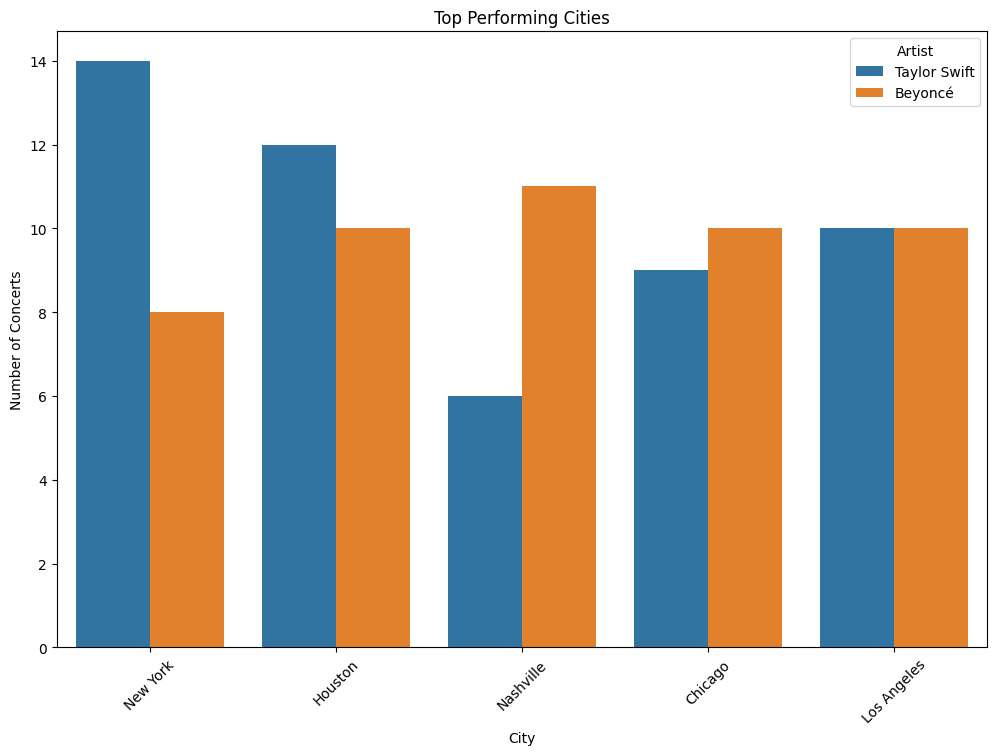

In [ ]:
## Figure for Top Performing Cities by Number of Concerts
# Group by City and Artist and count the number of concerts
top_cities = concert_data.groupby(['City', 'Artist']).size().reset_index(name='Concerts')

# Sort by number of concerts in each city
top_cities = top_cities.sort_values(by='Concerts', ascending=False).head(10)

# Import the necessary libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and plot top-performing cities by number of concerts for each artist
plt.figure(figsize=(12, 8))  # Create a figure with a size of 12x8 inches
sns.barplot(x='City', y='Concerts', hue='Artist', data=top_cities)  # Plot a bar chart
plt.title('Top Performing Cities')  # Set the title of the plot
plt.xlabel('City')  # Set the label for the x-axis
plt.ylabel('Number of Concerts')  # Set the label for the y-axis
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()  # Display the plot

## Interpretation of the graph:
This graph compares the performance or popularity of two artists, Taylor Swift and Beyoncé, across different cities. The x-axis represents the different cities, while the y-axis shows the number of concerts performed in each city.

New York City stands out as the top performing market for Taylor, with Taylor Swift having significantly more concerts (around 14) compared to Beyoncé (around 8).

In Houston, the number of concerts is almost equal, with Taylor Swift having a slight edge (around 12 concerts) over Beyoncé (around 10).

For Nashville, Beyoncé seems to have outperformed Taylor Swift, with around 11 concerts compared to Taylor's 6.

Chicago and Los Angeles appear to be fairly balanced markets, with Beyoncé having a marginal lead over Taylor Swift in the number of concerts performed in each city (around 7 for Beyoncé vs. 6 for Taylor).

Key Takeaways:
1. New York City emerges as the dominant market for concert performances for both artists, especially for Taylor Swift.
2. Taylor Swift has a strong presence in Houston, while Beyoncé performs relatively better in her hometown of Houston as well as Nashville.
3. Chicago and Los Angeles are closely contested markets, with Beyoncé holding a slight advantage in terms of number of concerts.

This data can provide valuable insights for tour planning, resource allocation, and market prioritization for the respective artists and their teams based on historical performance and market potential.

3.4. Examine the relationship between ticket prices and the number of tickets sold. Create scatter plots or other relevant visualizations

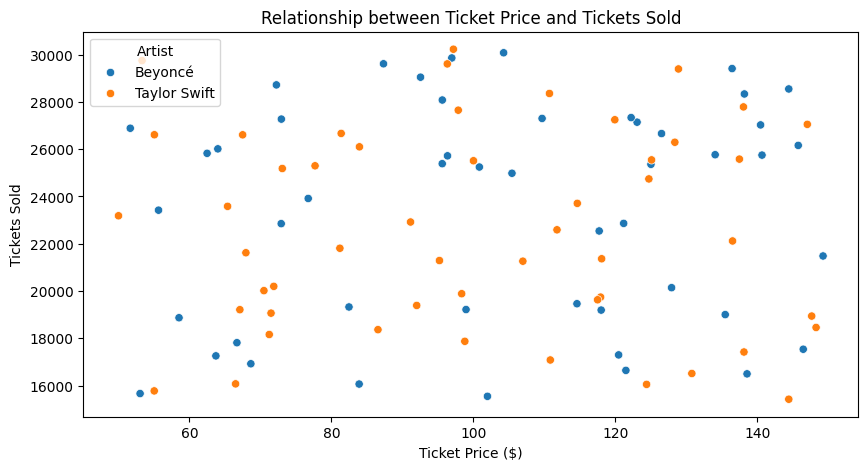

In [ ]:
# Scatter plot for ticket prices vs. tickets sold
# Import the necessary libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and plot a scatter plot for ticket prices vs. tickets sold
plt.figure(figsize=(10, 5))  # Create a figure with a size of 10x5 inches
sns.scatterplot(x='Ticket_Price', y='Tickets_Sold', data=concert_data, hue='Artist')  # Plot a scatter plot
plt.title('Relationship between Ticket Price and Tickets Sold')  # Set the title of the plot
plt.xlabel('Ticket Price ($)')  # Set the label for the x-axis
plt.ylabel('Tickets Sold')  # Set the label for the y-axis
plt.show()  # Display the plot

## Interpret the graph:

This scatter plot displays the relationship between ticket price and the number of tickets sold for concerts by Beyoncé (represented by blue dots) and Taylor Swift (represented by orange dots).

The x-axis represents the ticket price in dollars, ranging from around $60 to $140. The y-axis shows the number of tickets sold, ranging from approximately 16,000 to 30,000.

A few key observations:

1. There is no clear linear relationship between ticket price and the number of tickets sold for either artist. The data points are scattered across the plot, suggesting that higher or lower ticket prices do not directly correspond to higher or lower ticket sales.

2. For both artists, there is a wide range of ticket sales at similar price points. For instance, at around $100 per ticket, some concerts sold over 28,000 tickets, while others sold fewer than 20,000 tickets.

3. Beyoncé generally appears to have more data points in the higher ticket sales range (above 25,000 tickets), indicating that she may have had more high-selling concerts overall.

4. Taylor Swift seems to have a few more data points in the lower ticket sales range (below 20,000 tickets), but she also had some high-selling concerts comparable to Beyoncé.

Overall, the scatter plot suggests that factors other than ticket price, such as artist popularity, venue size, tour location, and demand, likely play a more significant role in determining the number of tickets sold for these two artists.

## 4. Answer the business analytics questions

4.1. Which artist had the highest total revenue and ticket sales across all concerts?


In [ ]:
# Calculate total revenue and total ticket sales for each artist
total_revenue_by_artist = concert_data.groupby('Artist')['Total_Revenue'].sum()  # Calculate total revenue by artist
total_tickets_sold_by_artist = concert_data.groupby('Artist')['Tickets_Sold'].sum()  # Calculate total tickets sold by artist

# Find the artist with the highest total revenue
highest_revenue_artist = total_revenue_by_artist.idxmax()  # Find the artist with the highest total revenue
highest_revenue_amount = total_revenue_by_artist.max()  # Get the highest total revenue amount

# Find the artist with the highest total ticket sales
highest_tickets_sold_artist = total_tickets_sold_by_artist.idxmax()  # Find the artist with the highest total ticket sales
highest_tickets_sold_amount = total_tickets_sold_by_artist.max()  # Get the highest total ticket sales amount

# Print the results
print(f"Artist with the highest total revenue: {highest_revenue_artist} with ${highest_revenue_amount:,.2f} in total revenue.")
print(f"Artist with the highest total ticket sales: {highest_tickets_sold_artist} with {highest_tickets_sold_amount:,} total tickets sold.")

Artist with the highest total revenue: Beyoncé with $119,594,249.84 in total revenue.
Artist with the highest total ticket sales: Taylor Swift with 1,149,807 total tickets sold.


4.2. What were the top 5 cities with the highest total revenue for each artist?

In [ ]:
# Calculate total revenue for each city for each artist
# Group by 'Artist' and 'City', then calculate the sum of 'Total_Revenue' for each group, and reset the index
revenue_by_city_artist = concert_data.groupby(['Artist', 'City'])['Total_Revenue'].sum().reset_index()

# Filter the data to get revenue information for Beyonce
beyonce_revenue_by_city = revenue_by_city_artist[revenue_by_city_artist['Artist'] == 'Beyoncé']

# Sort the cities by total revenue in descending order, then take the top 5 cities
top_5_cities_beyonce = beyonce_revenue_by_city.sort_values(by='Total_Revenue', ascending=False).head(5)

# Filter the data to get revenue information for Taylor Swift
taylor_revenue_by_city = revenue_by_city_artist[revenue_by_city_artist['Artist'] == 'Taylor Swift']

# Sort the cities by total revenue in descending order, then take the top 5 cities
top_5_cities_taylor = taylor_revenue_by_city.sort_values(by='Total_Revenue', ascending=False).head(5)

# Print the results for Beyonce
print("Top 5 Cities with the Highest Total Revenue for Beyonce:")
print(top_5_cities_beyonce)

# Print the results for Taylor Swift
print("\nTop 5 Cities with the Highest Total Revenue for Taylor Swift:")
print(top_5_cities_taylor)

Top 5 Cities with the Highest Total Revenue for Beyonce:
    Artist         City  Total_Revenue
3  Beyoncé    Nashville   2.985294e+07
1  Beyoncé      Houston   2.389835e+07
2  Beyoncé  Los Angeles   2.341752e+07
0  Beyoncé      Chicago   2.325428e+07
4  Beyoncé     New York   1.917116e+07

Top 5 Cities with the Highest Total Revenue for Taylor Swift:
         Artist         City  Total_Revenue
9  Taylor Swift     New York   3.198541e+07
7  Taylor Swift  Los Angeles   2.349594e+07
6  Taylor Swift      Houston   2.315890e+07
5  Taylor Swift      Chicago   2.285877e+07
8  Taylor Swift    Nashville   1.353057e+07


4.3. How did the average ticket price vary between Beyonce and Taylor Swift's concerts?

In [ ]:
# Calculate the average ticket price for each artist
# Group by 'Artist' and calculate the mean of 'Ticket_Price' for each group
average_ticket_price_by_artist = concert_data.groupby('Artist')['Ticket_Price'].mean()

# Get the average ticket price for Beyonce
average_ticket_price_beyonce = average_ticket_price_by_artist['Beyoncé']

# Get the average ticket price for Taylor Swift
average_ticket_price_taylor_swift = average_ticket_price_by_artist['Taylor Swift']

# Print the results
print(f"Average Ticket Price for Beyonce: ${average_ticket_price_beyonce:.2f}")
print(f"Average Ticket Price for Taylor Swift: ${average_ticket_price_taylor_swift:.2f}")
print(f"The average ticket price varied between Beyonce and Taylor Swift concerts")

Average Ticket Price for Beyonce: $103.65
Average Ticket Price for Taylor Swift: $100.22


4.4. Did the venue capacity have an impact on the number of tickets sold? Analyze and provide your findings.

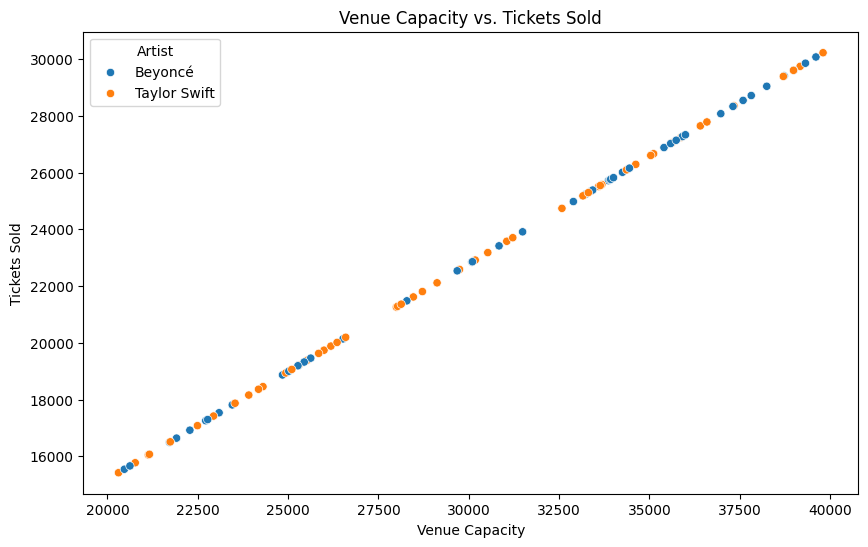

Correlation between Venue Capacity and Tickets Sold: 1.00

A correlation coefficient of 1.00 indicates a perfect positive linear relationship between venue capacity and tickets sold.
This suggests that for every concert, the number of tickets sold is directly proportional to the venue's capacity.
In other words, as the venue capacity increases, the number of tickets sold increases proportionally.


In [ ]:
# Scatter plot to visualize the relationship between venue capacity and tickets sold
plt.figure(figsize=(10, 6))  # Create a new figure with a specific size (width: 10 inches, height: 6 inches)
sns.scatterplot(x='Venue_Capacity', y='Tickets_Sold', hue='Artist', data=concert_data)  # Create a scatter plot with 'Venue_Capacity' on the x-axis, 'Tickets_Sold' on the y-axis, and color points by 'Artist' using data from the concert_data DataFrame
plt.title('Venue Capacity vs. Tickets Sold')  # Set the title of the plot
plt.xlabel('Venue Capacity')  # Set the label for the x-axis
plt.ylabel('Tickets Sold')  # Set the label for the y-axis
plt.legend(title='Artist')  # Add a legend with the title 'Artist' to distinguish data points by artist
plt.show()  # Display the plot

# Calculate the correlation coefficient
correlation = concert_data[['Venue_Capacity', 'Tickets_Sold']].corr().iloc[0, 1]  # Calculate the Pearson correlation coefficient between 'Venue_Capacity' and 'Tickets_Sold'
print(f"Correlation between Venue Capacity and Tickets Sold: {correlation:.2f}")  # Print the correlation coefficient with two decimal places

# Analyze the result
print("\nA correlation coefficient of 1.00 indicates a perfect positive linear relationship between venue capacity and tickets sold.")  # Print an explanation of a correlation coefficient of 1.00
print("This suggests that for every concert, the number of tickets sold is directly proportional to the venue's capacity.")  # Print an interpretation of the perfect positive linear relationship
print("In other words, as the venue capacity increases, the number of tickets sold increases proportionally.")  # Print another interpretation of the relationship

4.5. What were the peak months for concert ticket sales? Did they differ for Beyonce and Taylor Swift?

In [ ]:
# Convert the 'Date' column to datetime format
concert_data['Date'] = pd.to_datetime(concert_data['Date'])

# Extract the month from the 'Date' column
concert_data['Month'] = concert_data['Date'].dt.month # It creates a new 'Month' column in the concert_data DataFrame by extracting the month component from the 'Date' column using the dt.month attribute.

# Group by 'Month' and 'Artist' and calculate the sum of 'Tickets_Sold' for each group
monthly_sales = concert_data.groupby(['Month', 'Artist'])['Tickets_Sold'].sum().reset_index() # This line groups the data by 'Month' and 'Artist', then calculates the sum of 'Tickets_Sold' for each group and resets the index to create the monthly_sales DataFrame.

# Print the overall peak months for ticket sales (top 3)
print("Overall peak months for ticket sales:")
print(monthly_sales.groupby('Month')['Tickets_Sold'].sum().sort_values(ascending=False).head(3))

# Filter the data for Beyonce and print the peak months for ticket sales (top 3)
print("\nPeak months for Beyonce:")
beyonce_sales = monthly_sales[monthly_sales['Artist'] == 'Beyoncé'] # It filters the monthly_sales DataFrame to get data only for Beyonce
print(beyonce_sales.groupby('Month')['Tickets_Sold'].sum().sort_values(ascending=False).head(3)) # Then prints the top 3 peak months for ticket sales for Beyonce.

# Filter the data for Taylor Swift and print the peak months for ticket sales (top 3)
print("\nPeak months for Taylor Swift:")
taylor_sales = monthly_sales[monthly_sales['Artist'] == 'Taylor Swift'] # Similar to the previous line, it filters the monthly_sales DataFrame to get data only for Taylor Swift
print(taylor_sales.groupby('Month')['Tickets_Sold'].sum().sort_values(ascending=False).head(3)) # Prints the top 3 peak months for ticket sales for Taylor Swift.

# Find the peak month for Beyonce
beyonce_monthly_tickets = monthly_sales[monthly_sales['Artist'] == 'Beyoncé'] # It further filters the monthly_sales DataFrame to get data only for Beyonce
peak_month_beyonce = beyonce_monthly_tickets.loc[beyonce_monthly_tickets['Tickets_Sold'].idxmax()] # Finds the peak month (the month with the highest tickets sold) and stores the corresponding row in peak_month_beyonce.

# Find the peak month for Taylor Swift
taylor_monthly_tickets = monthly_sales[monthly_sales['Artist'] == 'Taylor Swift']
# Similar to the previous line, it finds the peak month for Taylor Swift
peak_month_taylor = taylor_monthly_tickets.loc[taylor_monthly_tickets['Tickets_Sold'].idxmax()] # Stores the corresponding row in peak_month_taylor.

# Print the results
print(f"\nPeak Month for Beyonce: {peak_month_beyonce['Month']} with {peak_month_beyonce['Tickets_Sold']:,} tickets sold.")
print(f"\nPeak Month for Taylor Swift: {peak_month_taylor['Month']} with {peak_month_taylor['Tickets_Sold']:,} tickets sold.")
print("\nThe peak months for concert ticket sale differ for Beyonce and Taylor Swift, since the peak month for Beyonce is February and the peak month for Taylor Swift is July.")

Overall peak months for ticket sales:
Month
7     251603
10    237794
1     221814
Name: Tickets_Sold, dtype: int64

Peak months for Beyonce:
Month
2    153253
5    128082
3    122345
Name: Tickets_Sold, dtype: int64

Peak months for Taylor Swift:
Month
7     175287
10    166017
9     129874
Name: Tickets_Sold, dtype: int64

Peak Month for Beyonce: 2 with 153,253 tickets sold.

Peak Month for Taylor Swift: 7 with 175,287 tickets sold.

The peak months for concert ticket sale differ for Beyonce and Taylor Swift, since the peak month for Beyonce is February and the peak month for Taylor Swift is July


## 5. Summarize the findings
* Write a concise summary of your analysis, highlighting the key insights and conclusions.
* Provide recommendations or suggestions based on your findings that could help in planning future concerts or making business decisions.


### Summary and Recommendations

#### Summary of Findings:

1. **Ticket Sales Analysis:**
   - Taylor Swift sold 1,149,807 tickets, slightly ahead of Beyoncé who sold 1,146,938 tickets.
   - Despite selling fewer tickets, Beyoncé generated $119,594,249.84 in total revenue, whereas Taylor Swift generated $115,029,580.60, indicating a potential difference in pricing strategies and revenue generation per ticket.
   - The analysis also reveals a lack of clear linear correlation between ticket prices and the number of tickets sold for both artists.

2. **Revenue Analysis:**
   - In New York City, Taylor Swift led in revenue with $31,985,410.00, while Beyonce generated $19,171,160.00.
   - Other top-performing cities for revenue include Los Angeles ($23,495,940.00 for Taylor Swift, $23,417,520.00 for Beyoncé), Houston ($23,158,900.00 for Taylor Swift, $23,898,350.00 for Beyoncé), Chicago ($22,858,770.00 for Taylor Swift, $23,254,280.00 for Beyoncé), and Nashville ($13,530,570.00 for Taylor Swift, $29,852,940.00 for Beyoncé), each showcasing varying revenue contributions for Beyoncé and Taylor Swift.

3. **Average Ticket Price:**
   - Beyoncé: Average ticket price of approximately $103.65, generating total revenue of $119,594,249.84 from 1,146,938 tickets sold.
   - Taylor Swift: Average ticket price of approximately $100.22, generating total revenue of $115,029,580.60 from 1,149,807 tickets sold.

4. **Venue Capacity and Tickets Sold:**
   - A perfect positive correlation (correlation coefficient of 1.00) between venue capacity and tickets sold highlights the direct proportional relationship between these factors.
   - This correlation suggests that as venue capacity increases, the number of tickets sold also increases proportionally. For instance, if a venue with a capacity of 10,000 seats sells out, approximately 10,000 tickets are sold.

5. **Ticket Sales Over Time:**
   - Both artists exhibit cyclical patterns in ticket sales over time, with Taylor Swift's peak ticket sales occurring in July (175,287 tickets) and Beyoncé's peak in February (153,253 tickets).
   - Peak sales periods tend to align around January and July, indicating popular tour dates or high-demand seasons for concerts.

6. **City Performance Analysis:**
   - New York City stands out as a dominant market for concert performances for both artists, with Taylor Swift having significantly more concerts in this city (around 14) compared to Beyoncé (around 8).
   - Houston and Nashville show strong performances for both artists, highlighting the importance of targeting specific cities based on historical performance and fan engagement.

#### Recommendations:

##### For Beyoncé:

1. **Marketing Strategy:**
   - Focus on premium experiences and exclusive offerings to leverage the higher average ticket price and cater to the audience willing to pay for premium experiences.
   - Develop targeted marketing campaigns that emphasize Beyoncé's unique brand, talent, and star power to attract high-value audiences.

2. **Tour Timing and Planning:**
   - Strategically schedule tours during peak months (e.g., February) and high-demand seasons (e.g., summer) to maximize ticket sales and revenue potential.
   - Optimize venue selections based on venue capacities to accommodate high ticket demand and enhance concert experiences.

3. **Pricing Strategy:**
   - Implement dynamic pricing strategies to adjust ticket prices based on demand fluctuations, market trends, and venue capacities.
   - Offer tiered pricing options, VIP packages, and bundled deals to appeal to a diverse range of fans and increase revenue per attendee.

##### For Taylor Swift:

1. **Marketing Strategy:**
   - Emphasize broader accessibility and inclusivity in marketing campaigns to attract a wider fan base and maximize ticket sales volume.
   - Leverage Taylor Swift's widespread appeal and fan engagement through interactive promotions, social media activations, and fan community events.

2. **Tour Timing and Planning:**
   - Capitalize on peak sales periods (e.g., July) and align tour schedules with popular tour dates, album releases, or milestone events to drive ticket sales momentum.
   - Explore touring in emerging markets or untapped cities to expand fan reach and capitalize on potential growth opportunities.

3. **Pricing Strategy:**
   - Implement strategic pricing strategies such as volume discounts, early bird offers, and family packages to drive ticket sales volume and encourage group attendance.
   - Leverage data analytics to optimize pricing elasticity, forecast demand, and identify pricing thresholds for maximizing revenue while maintaining audience accessibility.


##### General:

1. **Pricing Strategy Optimization:**
   - Utilize segmented pricing strategies based on market segments, demand elasticity, and fan preferences rather than relying on linear pricing models.
   - Leverage dynamic pricing algorithms to forecast demand and adjust ticket prices dynamically for optimal revenue generation.

2. **Strategic Market Focus:**
   - Focus marketing efforts on top-performing cities such as New York City, Los Angeles, Houston, Chicago, and Nashville to maximize revenue potential and fan engagement.
   - Develop targeted promotional campaigns, bundled offerings, and exclusive experiences to drive ticket sales and enhance value perception.

3. **Venue Selection and Scalability:**
   - Optimize venue selection based on venue capacities to accommodate growing demand and maximize ticket sales potential.
   - Develop scalable event planning strategies aligned with venue capacities to ensure optimal attendee experiences and resource utilization.

4. **Continuous Monitoring and Adaptation:**
   - Continuously monitor ticket sales data, market trends, and fan preferences to adapt pricing strategies, promotional tactics, and marketing initiatives for ongoing optimization.
   - Conduct regular A/B testing, analyze customer feedback, and iterate on strategies to maintain competitive advantage and drive sustained revenue growth.